In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Reshape
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam

In [38]:
# cargamos los embeddings generados previamente
X_train = np.load("../data/processed/Elmo/mean/X_train_elmo_mean.npy")
X_test  = np.load("../data/processed/Elmo/mean/X_test_elmo_mean.npy")

# cargamos las etiquetas con el mismo split que usamos al generar los embeddings
df = pd.read_csv('../data/raw/tcga_simple_train.csv')
_, _, y_train, y_test = train_test_split(df['text'], df['t'], test_size=0.2, random_state=42)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Clases:", le.classes_)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Clases: ['T1' 'T2' 'T3' 'T4']
X_train: (4126, 1024), X_test: (1032, 1024)
y_train: (4126,), y_test: (1032,)


c:\Users\hugo\PLN1\OncoNLP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 1, 256)         │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 1, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_10         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,732 (1.41 MB)

 Trainable params: 369,732 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Pesos por clase: {np.int64(0): np.float64(0.9851957975167144), np.int64(1): np.float64(0.7458423716558207), np.int64(2): np.float64(0.807752545027408), np.int64(3): np.float64(2.4618138424821003)}
Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2165 - loss: 1.4565 - val_accuracy: 0.0993 - val_loss: 1.4370
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2001 - loss: 1.4067 - val_accuracy: 0.3172 - val_loss: 1.3947
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2844 - loss: 1.3912 - val_accuracy: 0.2639 - val_loss: 1.3972
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2448 - loss: 1.3845 - val_accuracy: 0.2906 - val_loss: 1.4014
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2472 - loss: 1.3837 - val_accuracy: 0.2785 - val_loss: 1.3596
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2540 - loss: 1.3813 - val_accuracy: 0.2906 - val_loss: 1.3675
Epoch 7/200
233/233 ━━━━━━━━━

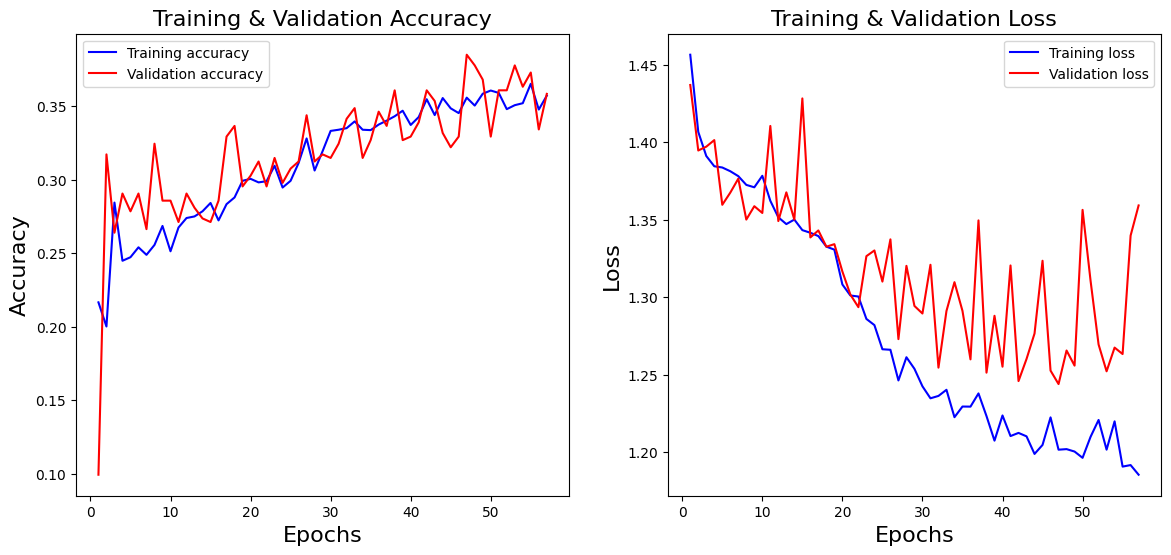

In [39]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Conv1D(filters=128, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=64, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

num_clases = len(le.classes_)

from tensorflow.keras.regularizers import l2
from sklearn.metrics import f1_score, classification_report

model = Sequential()
model.add(Conv1D(filters=256, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[2])))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.0005)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_clases, activation='softmax'))

model.summary()

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop]
)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.4f} | Accuracy: {accuracy:.4f}")

# evaluacion con f1
y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)

f1_macro = f1_score(y_test, y_pred_clases, average='macro')
f1_weighted = f1_score(y_test, y_pred_clases, average='weighted')

print(f"F1 Macro:    {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

history_dict    = history.history
loss_values     = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy_vals   = history_dict['accuracy']
val_accuracy    = history_dict['val_accuracy']
epochs          = range(1, len(loss_values) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(epochs, accuracy_vals, 'b',   label='Training accuracy')
ax[0].plot(epochs, val_accuracy,  'red', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()

ax[1].plot(epochs, loss_values,     'b',   label='Training loss')
ax[1].plot(epochs, val_loss_values, 'red', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

plt.show()

In [40]:
# ver distribucion de clases
import pandas as pd

df_dist = pd.Series(y_train).value_counts().sort_index()
print("Distribución clases (train):")
for i, count in enumerate(df_dist):
    print(f"  {le.classes_[i]}: {count} muestras")

# ver el f1 por clase del ultimo modelo
y_pred = model.predict(X_test)
y_pred_clases = np.argmax(y_pred, axis=1)
print("\n", classification_report(y_test, y_pred_clases, target_names=le.classes_))

Distribución clases (train):
  T1: 1047 muestras
  T2: 1383 muestras
  T3: 1277 muestras
  T4: 419 muestras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

               precision    recall  f1-score   support

          T1       0.39      0.76      0.51       255
          T2       0.38      0.22      0.28       369
          T3       0.43      0.15      0.22       306
          T4       0.24      0.50      0.32       102

    accuracy                           0.36      1032
   macro avg       0.36      0.41      0.34      1032
weighted avg       0.38      0.36      0.33      1032

